<div style="
    background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
    padding: 35px;
    border-radius: 14px;
    text-align: center;
    box-shadow: 0px 6px 20px rgba(0,0,0,0.3);
">
    <h1 style="
        color: #E3F2FD;
        font-family: 'Segoe UI', sans-serif;
        font-size: 42px;
        margin-bottom: 15px;
        letter-spacing: 1px;
    ">
        Credit Risk Modeling
    </h1>
    <p style="
        color: #90CAF9;
        font-size: 18px;
        font-family: 'Segoe UI', sans-serif;
        text-align: center;
        margin: 0;
    ">
        ML Project By Tanmay Pakori
    </p>
</div>

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split

In [2]:
# load datasets
df_customers = pd.read_csv('datasets/customers.csv')
df_loans= pd.read_csv('datasets/loans.csv')
df_bureau = pd.read_csv('datasets/bureau_data.csv')

In [3]:
# checking size of datasets
df_customers.shape, df_loans.shape,df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

In [4]:
# looking for primary and foreign keys to merge datasets
df_customers.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [5]:
df_loans.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [6]:
# merging two datasets
df = pd.merge(df_customers,df_loans,on='cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [7]:
# merging new dataset with bureau data to create combined final dataset
df = pd.merge(df,df_bureau, on='cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [8]:
# get a quick summary of your DataFrame.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [9]:
# Converting Target column (default) from boolean to numerical data type
df['default']=df['default'].astype(int)
# getting indivisual value counts
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

We can see there is class imbalance in our Target column

In [10]:
# We perform train-test split before preprocessing to prevent data leakage.
# Preprocessing steps such as scaling, encoding, and imputation learn patterns
# (e.g., mean, standard deviation, category mappings) from the data.
# These patterns must be learned only from the training set.

# If preprocessing is done before splitting, information from the test set
# unintentionally influences the training process (train-test contamination),
# leading to overly optimistic and biased model performance.

# In a real-world scenario, the model will only have access to past (training) data.
# Therefore, we first split the data, fit preprocessing on training data,
# and then apply the same transformations to test and future unseen data.

In [11]:
x = df.drop('default', axis=1)
y = df['default']

x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.25,random_state=42)

In [12]:
# combining train and test data for preprocessing
df_train = pd.concat([x_train,y_train],axis=1)
df_test = pd.concat([x_test,y_test],axis=1)

In [13]:
df_train.shape,df_test.shape

((37500, 33), (12500, 33))

<h3 align="center" style="color:blue">Data Cleaning</h3>

In [14]:
# finding null values
df_train.isnull().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 48
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [15]:
# checking unique values
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [16]:
# finding mode to replace null values as its categorical column
mode_residence = df_train.residence_type.mode()[0]
mode_residence

'Owned'

In [17]:
# filling null values with mode
df_train['residence_type'] = df_train['residence_type'].fillna(mode_residence)
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [18]:
# replace null values from test data with mode in residence_type column
df_test['residence_type'] = df_test['residence_type'].fillna(mode_residence)

In [19]:
# checking duplicate values
df_train.duplicated().sum()

np.int64(0)

In [20]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [21]:
# creating seperate list of continuos and categorical columns
columns_continuous = ['age', 'income', 'number_of_dependants', 'years_at_current_address', 'sanction_amount', 
                      'loan_amount', 'processing_fee', 'gst','net_disbursement', 'loan_tenure_months', 
                      'principal_outstanding','bank_balance_at_application', 'number_of_open_accounts', 
                      'number_of_closed_accounts', 'total_loan_months', 'delinquent_months','total_dpd', 
                      'enquiry_count', 'credit_utilization_ratio']
columns_categorical = ['gender', 'marital_status', 'employment_status', 'residence_type', 'city', 'state', 
                       'zipcode','loan_purpose','loan_type', 'default']
      

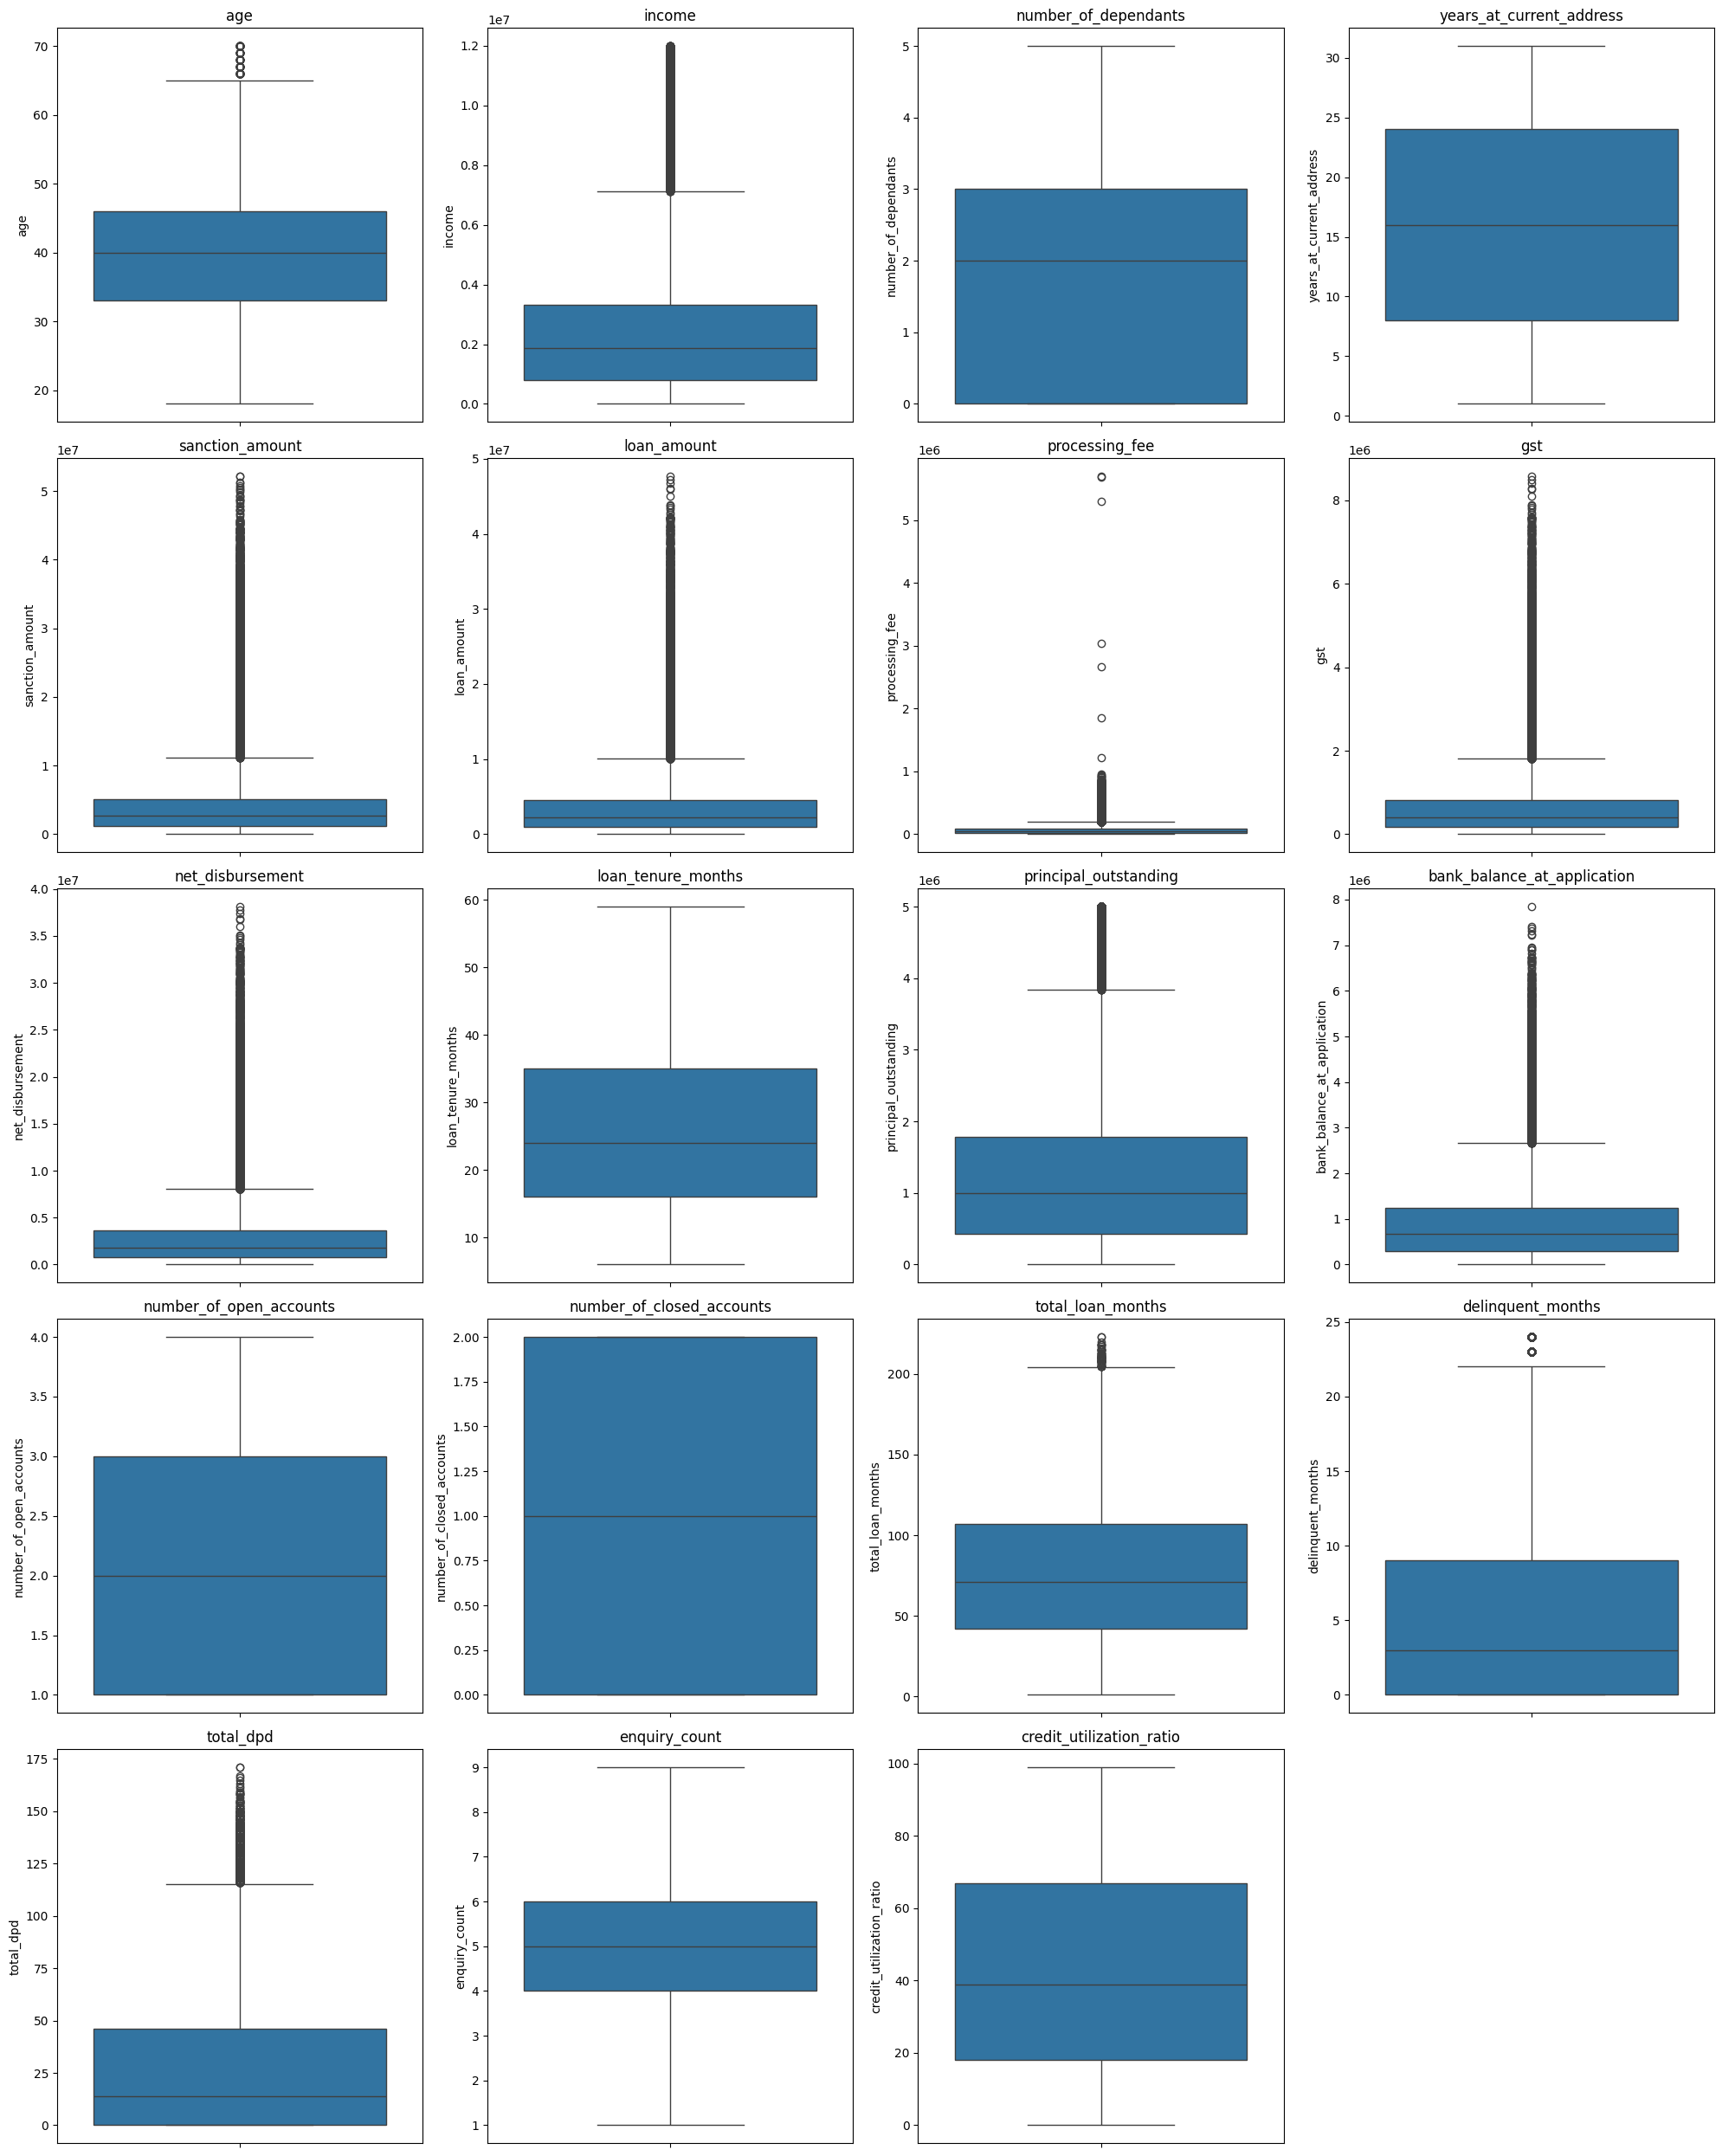

In [22]:
cols = columns_continuous

# number of rows needed
rows = math.ceil(len(cols) / 4)

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(cols, 1):
    plt.subplot(rows, 4, i)
    sns.boxplot(y=df_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

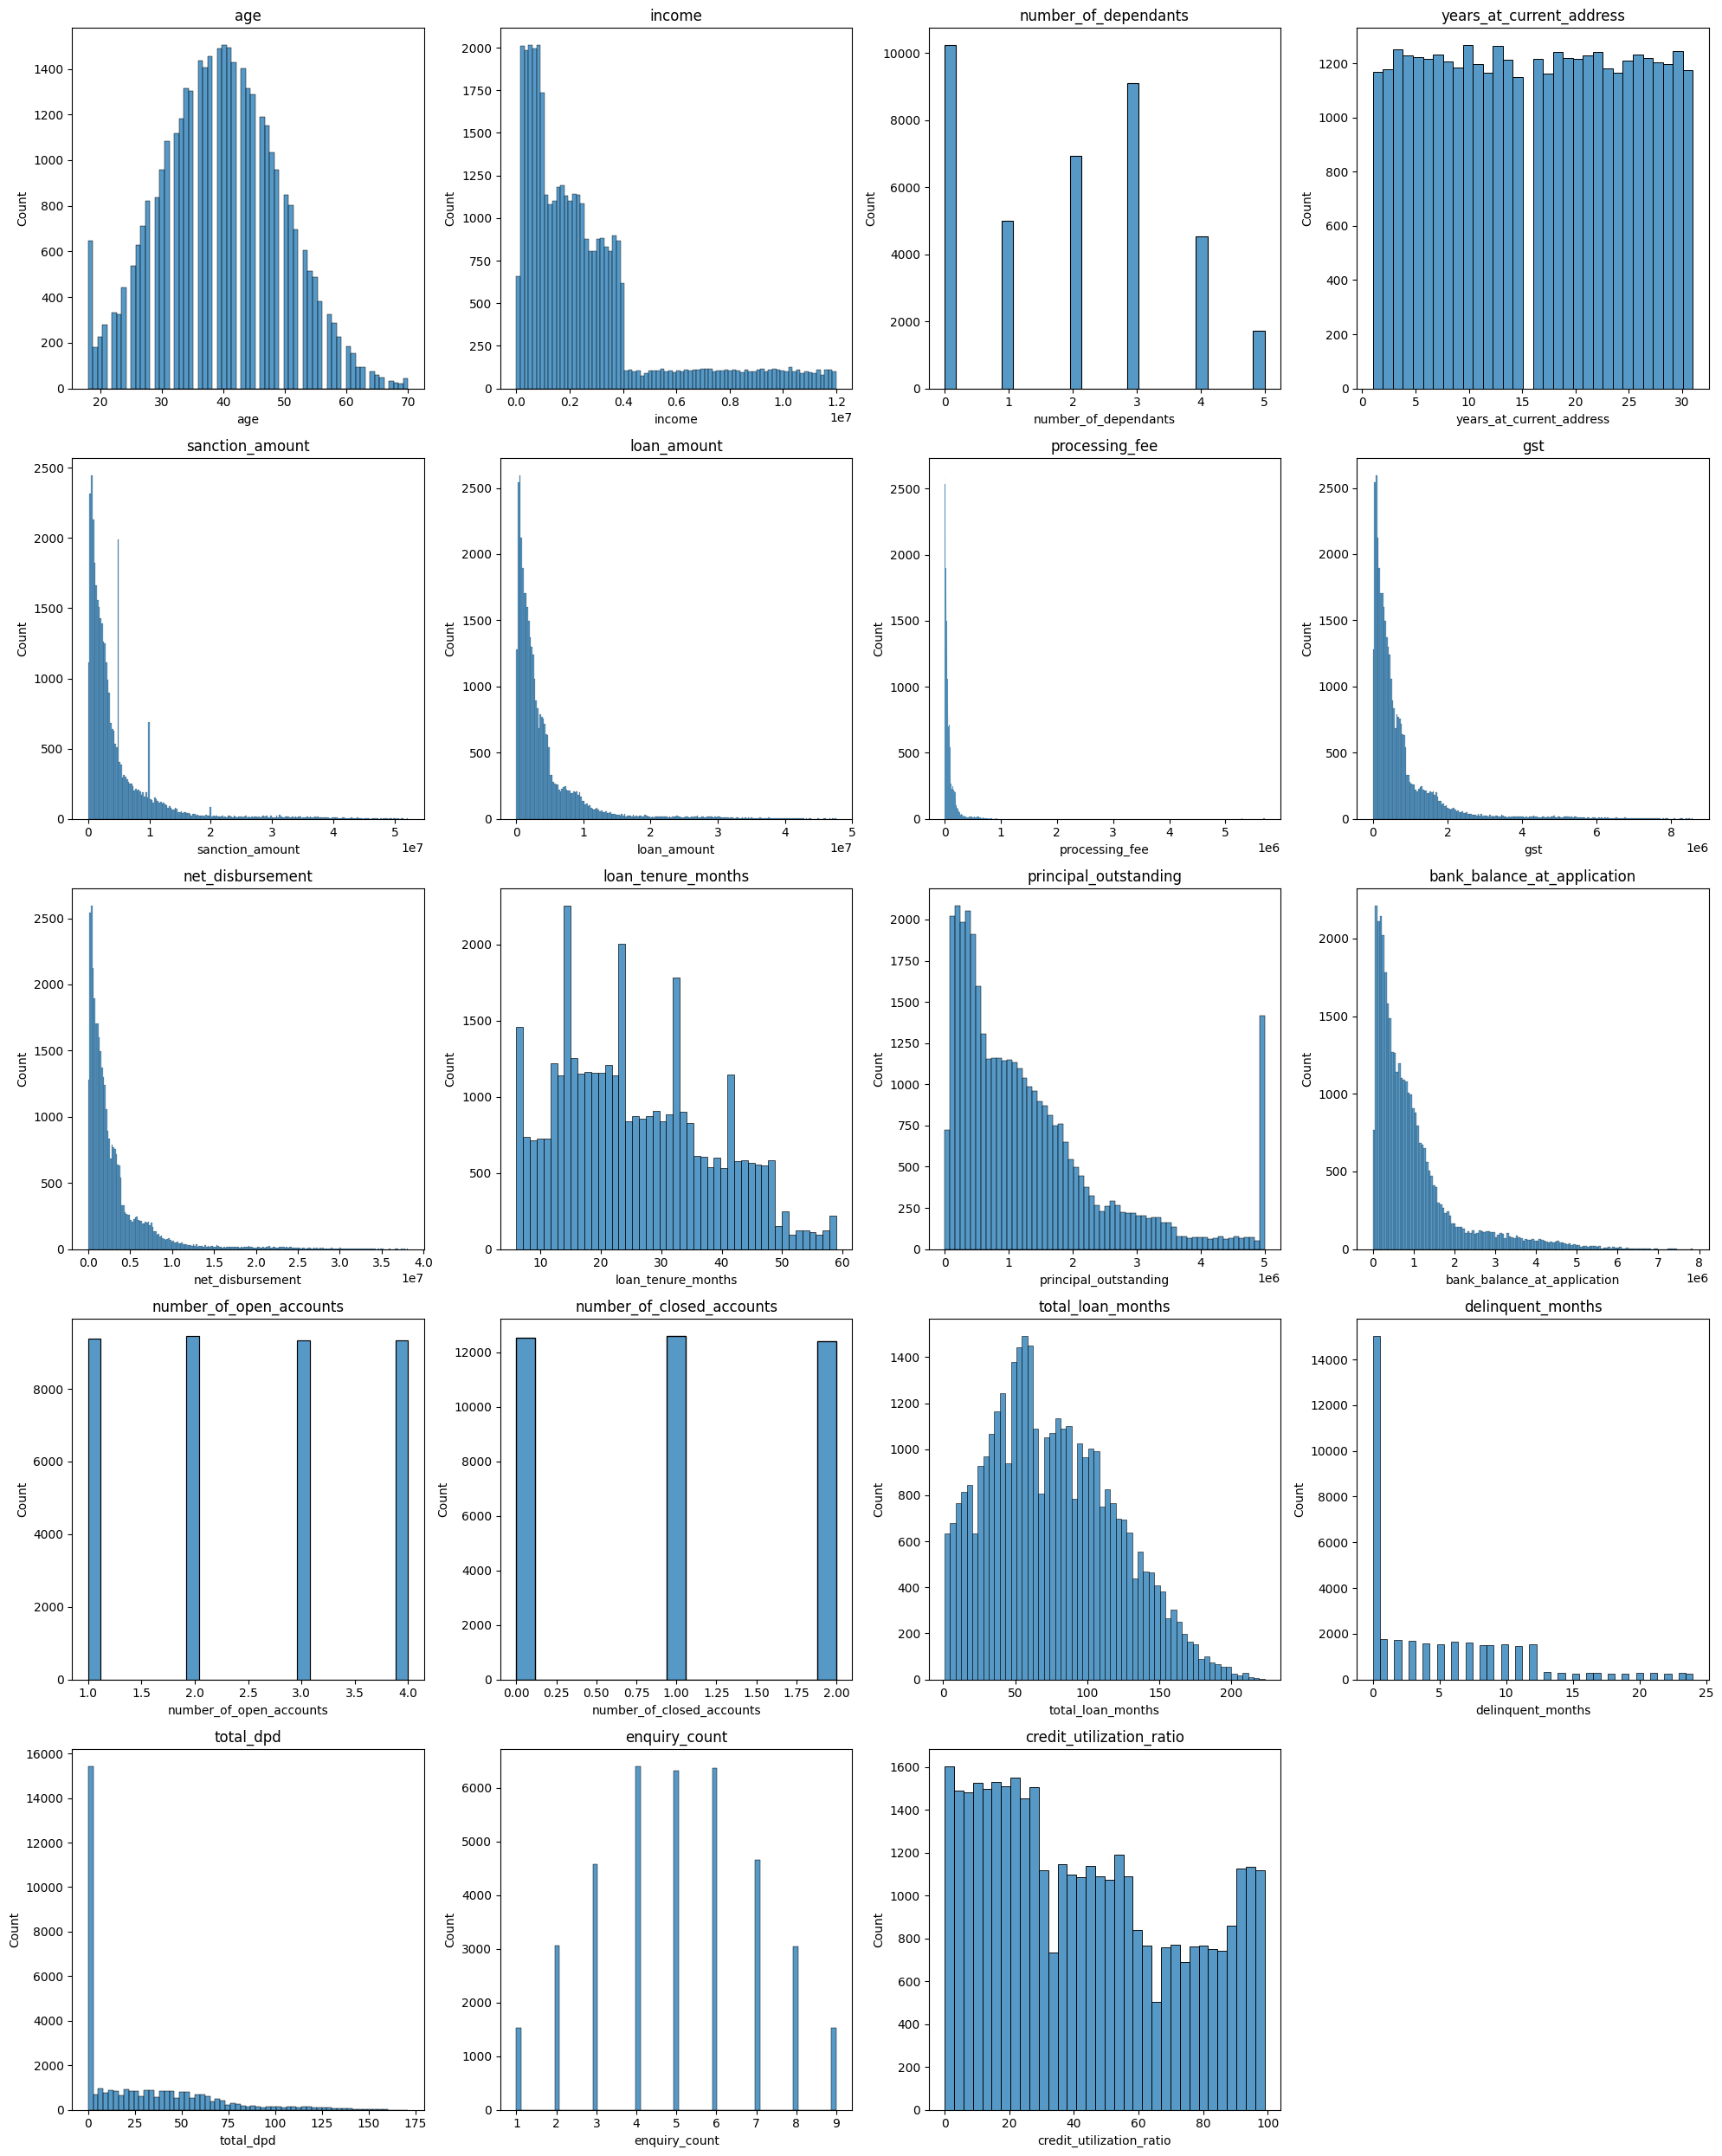

In [23]:
cols = columns_continuous

# number of rows needed
rows = math.ceil(len(cols) / 4)

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(cols, 1):
    plt.subplot(rows, 4, i)
    sns.histplot(x=df_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [24]:
# we analysed graphs and find out columns which need to be processed further

In [25]:
df_train.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,...,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
count,37500.000000,3.750000e+04,37500.000000,37500.000000,37500.000000,3.750000e+04,3.750000e+04,3.750000e+04,3.750000e+04,3.750000e+04,...,3.750000e+04,3.750000e+04,37500.00000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000
mean,39.564693,2.636055e+06,1.942507,15.994000,418768.573333,4.706707e+06,4.002797e+06,8.072411e+04,7.205034e+05,3.202237e+06,...,1.336077e+06,9.874674e+05,2.49648,0.996773,75.999653,4.891787,26.936107,5.003280,43.327813,0.085040
std,9.854235,2.624141e+06,1.535799,8.938145,168831.821515,6.288693e+06,5.400902e+06,1.208307e+05,9.721624e+05,4.320722e+06,...,1.213734e+06,1.045109e+06,1.11716,0.815046,43.705703,5.863999,32.925469,2.023875,29.355038,0.278945
min,18.000000,0.000000e+00,0.000000,1.000000,110001.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-1.000000e+00,0.000000e+00,1.00000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,33.000000,8.030000e+05,0.000000,8.000000,302001.000000,1.136000e+06,9.590000e+05,1.918000e+04,1.726200e+05,7.672000e+05,...,4.239310e+05,2.861895e+05,1.00000,0.000000,42.000000,0.000000,0.000000,4.000000,18.000000,0.000000
50%,40.000000,1.884000e+06,2.000000,16.000000,400001.000000,2.651000e+06,2.234000e+06,4.470000e+04,4.021200e+05,1.787200e+06,...,1.000882e+06,6.668250e+05,2.00000,1.000000,71.000000,3.000000,14.000000,5.000000,39.000000,0.000000
75%,46.000000,3.332000e+06,3.000000,24.000000,560001.000000,5.159000e+06,4.597250e+06,9.200000e+04,8.275050e+05,3.677800e+06,...,1.789092e+06,1.236740e+06,3.00000,2.000000,107.000000,9.000000,46.000000,6.000000,67.000000,0.000000
max,70.000000,1.199900e+07,5.000000,31.000000,700001.000000,5.217500e+07,4.766700e+07,5.698030e+06,8.580060e+06,3.813360e+07,...,5.000000e+06,7.846643e+06,4.00000,2.000000,223.000000,24.000000,171.000000,9.000000,99.000000,1.000000


In [26]:
# 56 lakhs processing fee...its an outlier
pd.set_option('display.float_format', '{:.2f}'.format)
df_train.processing_fee.describe()

count     37500.00
mean      80724.11
std      120830.65
min           0.00
25%       19180.00
50%       44700.00
75%       92000.00
max     5698029.90
Name: processing_fee, dtype: float64

In [27]:
IQR = 92000-19180
upper_limit = 92000+1.5*IQR
upper_limit

201230.0

In [28]:
df_train[df_train['processing_fee'] > 201230.0][['loan_amount','processing_fee']]

,loan_amount,processing_fee
10713,12836000,256720.00
10917,19522000,390440.00
12695,17788000,355760.00
44551,10417000,208340.00
22894,11993000,239860.00
...,...,...
43021,14572000,291440.00
11394,11738000,234760.00
2747,10796000,215920.00
28693,11125000,222500.00


In [29]:
# we will find rows where loan amount is less that processing fee
df_train[df_train['processing_fee'] > df_train['loan_amount']][['loan_amount','processing_fee']]

,loan_amount,processing_fee
23981,2234000,2669791.02
9898,3626000,5293543.52
47089,1738000,1858964.77
33705,3812000,5678020.86
12294,4639000,5698029.90
28174,966000,1214492.67
29305,2616000,3036378.01


In [30]:
# by talking with business manager we got to know our processing fee is maximum 3% so we will consider outliers having fee more than that
df_train[(df_train.processing_fee/df_train.loan_amount)>0.03][['loan_amount','processing_fee']]

,loan_amount,processing_fee
23981,2234000,2669791.02
9898,3626000,5293543.52
47089,1738000,1858964.77
33705,3812000,5678020.86
12294,4639000,5698029.90
28174,966000,1214492.67
29305,2616000,3036378.01


In [31]:
# team decided to remove this outliers
df_train_1 = df_train[(df_train.processing_fee/df_train.loan_amount)<0.03].copy()

In [32]:
# cross checking if all outliers removed or not
df_train_1[(df_train_1.processing_fee/df_train_1.loan_amount)>0.03][['loan_amount','processing_fee']]

,loan_amount,processing_fee


In [33]:
# applying same steps on test data
df_test = df_test[(df_test.processing_fee/df_test.loan_amount)<0.03].copy()
df_test.shape

(12498, 33)

In [34]:
columns_categorical

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

In [35]:
for col in columns_categorical:
    print(col,'-->',df_train[col].unique())

gender --> ['F' 'M']
marital_status --> ['Single' 'Married']
employment_status --> ['Salaried' 'Self-Employed']
residence_type --> ['Owned' 'Mortgage' 'Rented']
city --> ['Ahmedabad' 'Delhi' 'Lucknow' 'Bangalore' 'Jaipur' 'Hyderabad' 'Kolkata'
 'Pune' 'Chennai' 'Mumbai']
state --> ['Gujarat' 'Delhi' 'Uttar Pradesh' 'Karnataka' 'Rajasthan' 'Telangana'
 'West Bengal' 'Maharashtra' 'Tamil Nadu']
zipcode --> [380001 110001 226001 560001 302001 500001 700001 411001 600001 400001]
loan_purpose --> ['Home' 'Auto' 'Personal' 'Education' 'Personaal']
loan_type --> ['Secured' 'Unsecured']
default --> [0 1]


In [36]:
# in laon_purpose column there is spelling mistake of Personal so replaced it in both train and test data
df_train_1['loan_purpose']=df_train_1['loan_purpose'].replace('Personaal','Personal')
df_test['loan_purpose']=df_test['loan_purpose'].replace('Personaal','Personal')
df_train_1.loan_purpose.unique()

array(['Home', 'Auto', 'Personal', 'Education'], dtype=object)

In [37]:
# checking that gst should not be greater that 18% as per business rule and management
df_train_1[(df_train_1.gst/df_train_1.loan_amount)>0.18]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default


<h3 align="center" style="color:blue">Exploratory Data Analysis</h3>

In [38]:
columns_continuous

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

In [39]:
# undestanding age column with default(target column)
df_train_1.groupby("default")['age'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,34298.00,39.78,9.87,18.00,33.00,40.00,47.00,70.00
1,3189.00,37.25,9.37,18.00,31.00,37.00,44.00,70.00


**Insights**

1. Average age in the default group is little less (37.12) than the average (39.7) of the group that did not default
1. Variability (standard deviation) is mostly similar in both the groups
1. Both the groups have similar min and max ages

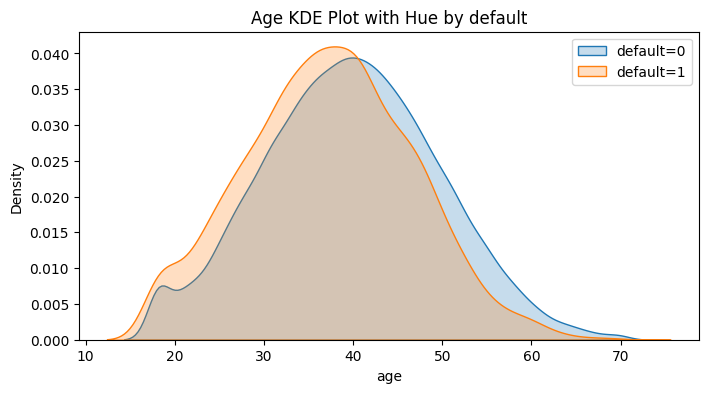

In [40]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['age'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['age'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Age KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**

1. Orange (defaulted) group is slightly shifted to left indicating that younger folks are more likely to default on their loans

### KDE for all columns

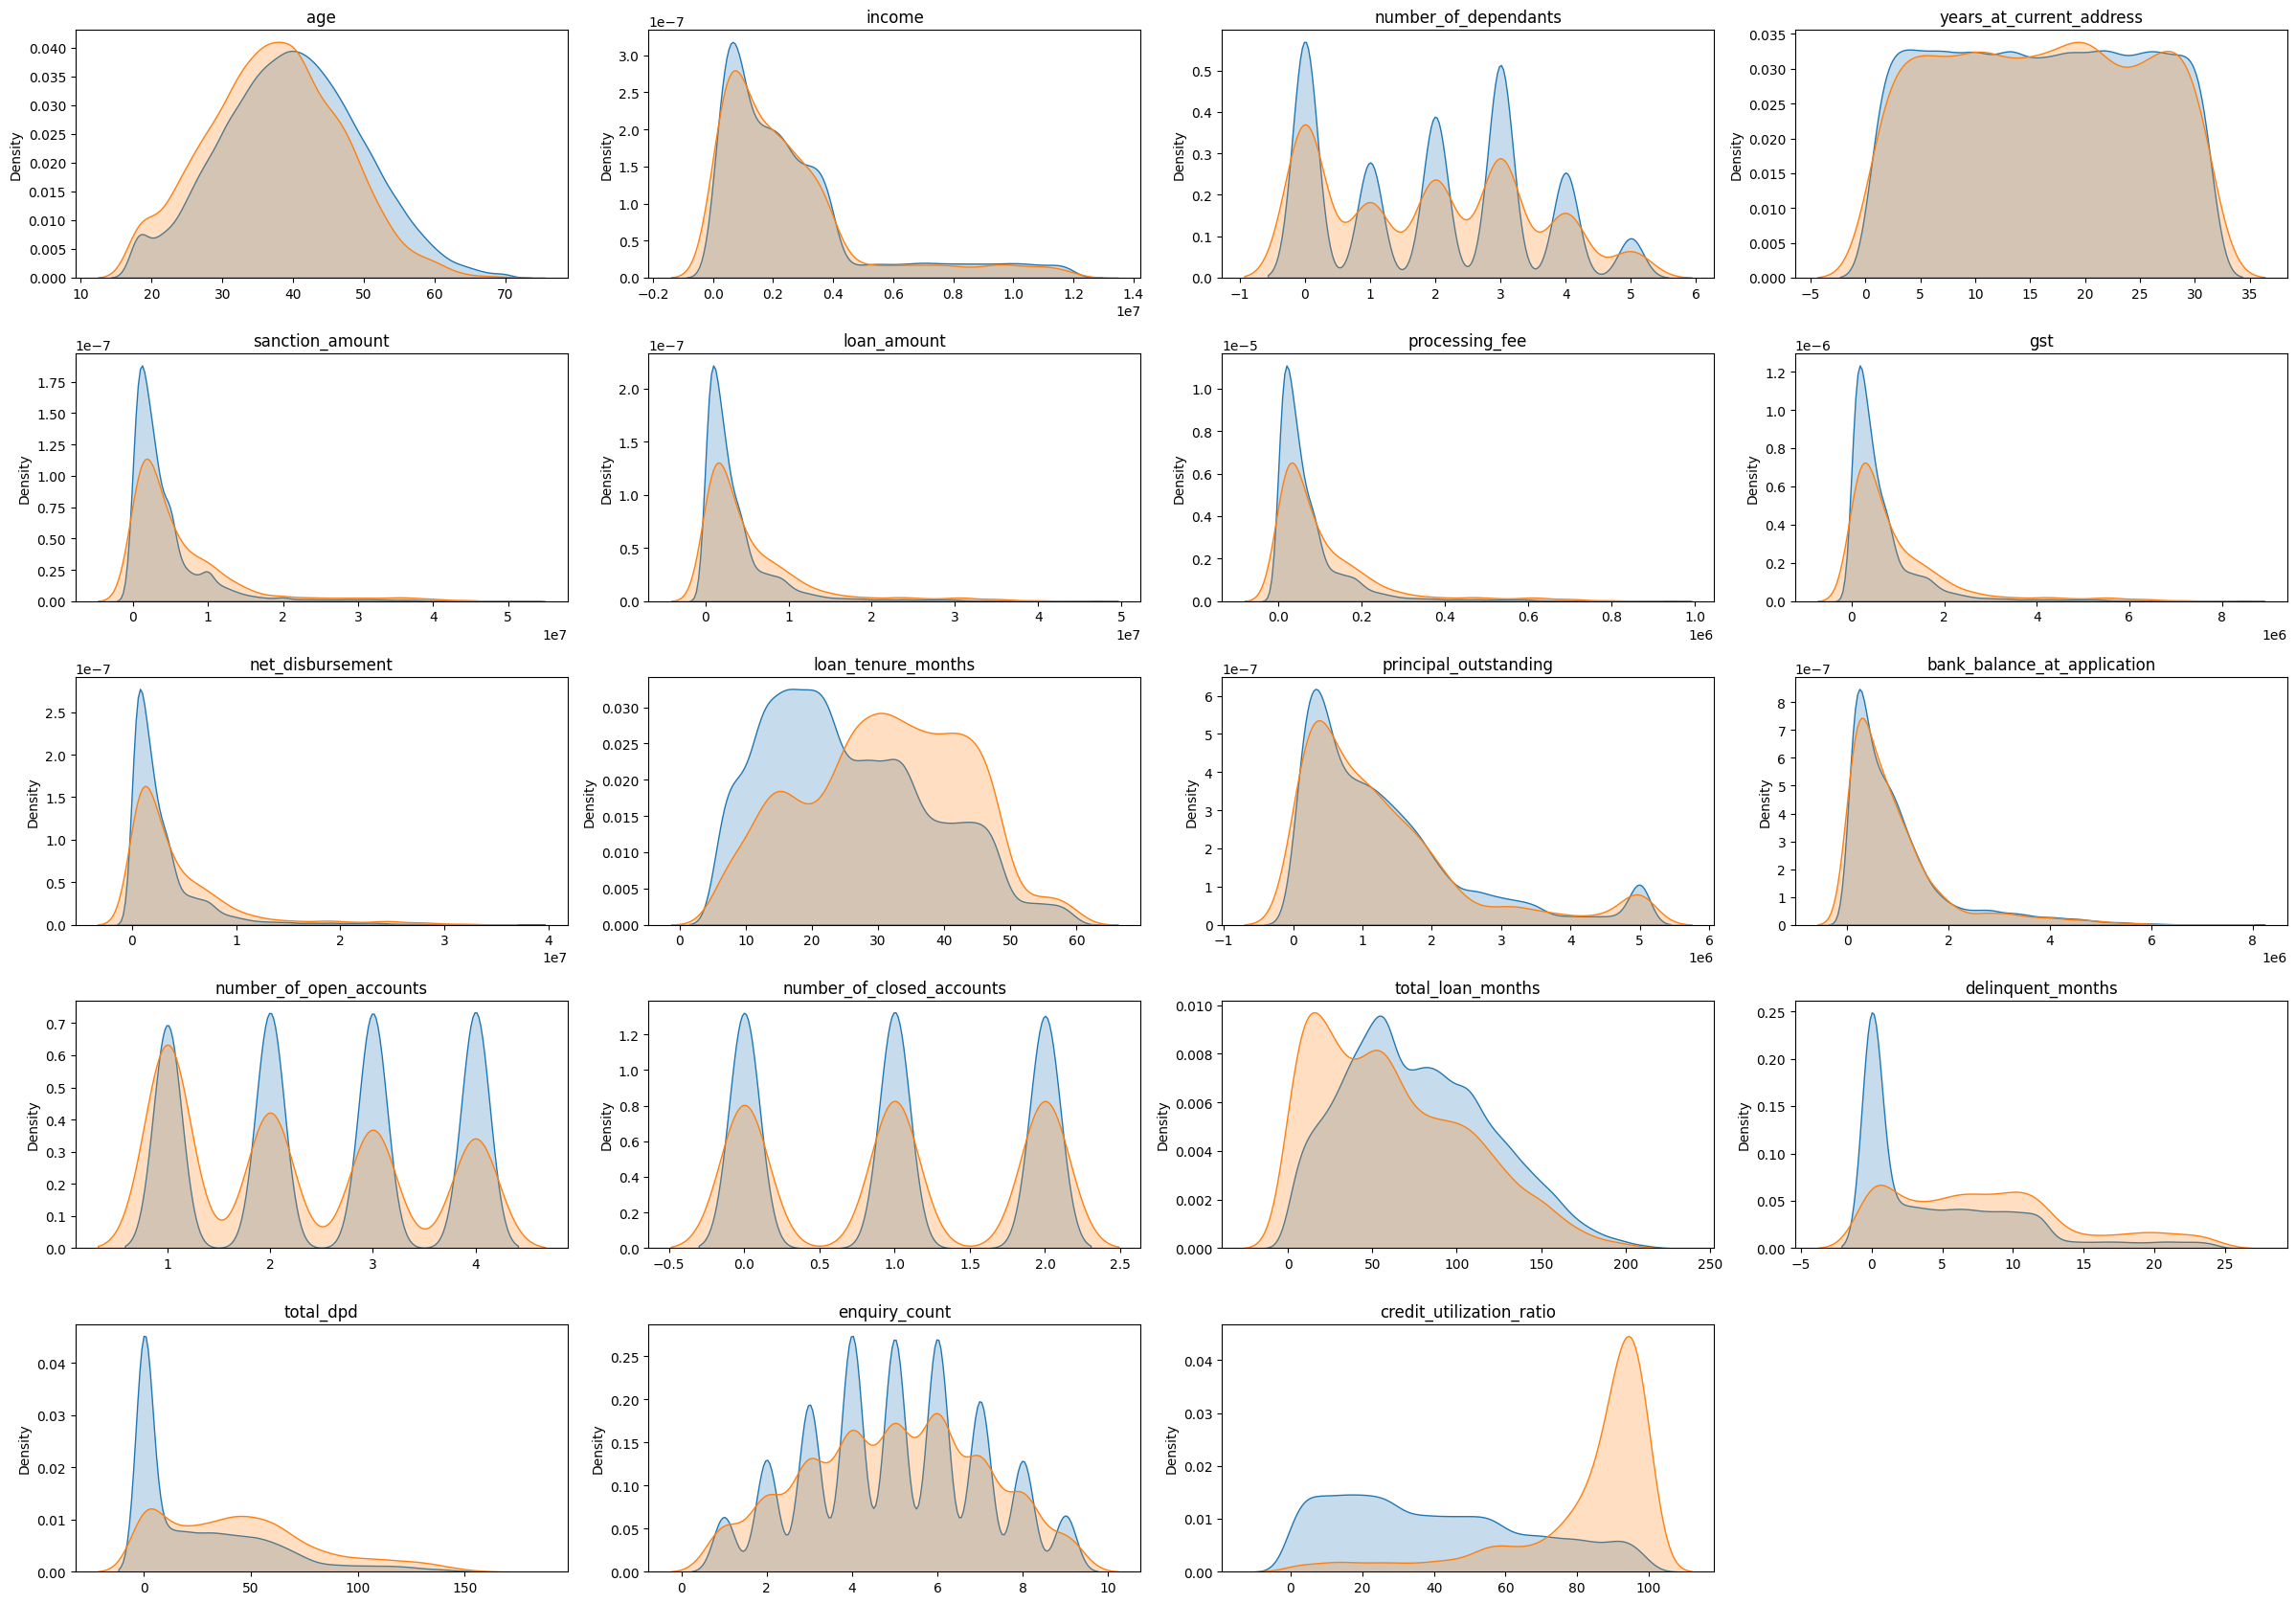

In [41]:
plt.figure(figsize=(24, 20))  # Width, height in inches

for i, col in enumerate(columns_continuous):
    plt.subplot(6, 4, i+1)  # 1 row, 4 columns, ith subplot
    sns.kdeplot(df_train_1[col][df_train_1['default']==0], fill=True, label='default=0')
    sns.kdeplot(df_train_1[col][df_train_1['default']==1], fill=True, label='default=1')
    plt.title(col)        
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

**Insights**

1. In columns: loan_tenure_months, delinquent_months, total_dpd, credit_utilization, higher values indicate high likelyhood of becoming a default. Hence these 4 looks like strong predictors
1. In remaining columns the distributions do not give any obvious insights
1. Why loan_amount and income did not give any signs of being strong predictors? May be when we combine these two and get loan to income ratio (LTI), that may have influence on the target variable. We will explore more later

<h3 align="center" style="color:blue">Feature Engineering</h3>

In [42]:
# business has given some ruless to create features 
# ex. Loan to income ratio,Delinquent months to loan month ratio,Avg DPD per delinquent month

In [43]:
df_train_1["loan_to_income"]=df_train_1["loan_amount"]/df_train_1["income"]

df_test["loan_to_income"]=df_test["loan_amount"]/df_test["income"]

df_train_1["loan_to_income"].describe()

count   37487.00
mean        1.55
std         0.97
min         0.30
25%         0.77
50%         1.16
75%         2.45
max         4.57
Name: loan_to_income, dtype: float64

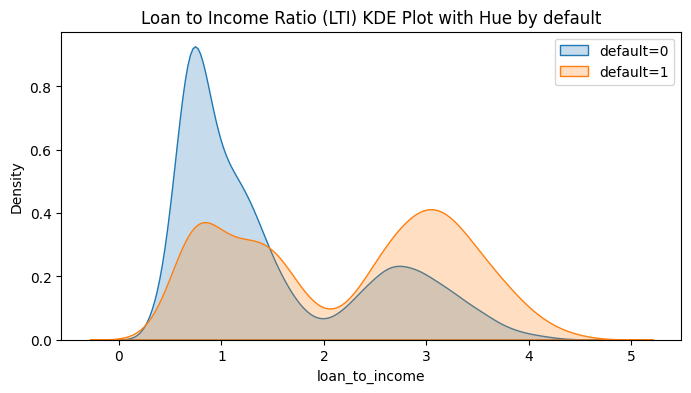

In [44]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['loan_to_income'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['loan_to_income'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Loan to Income Ratio (LTI) KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**
1. Blue graph has majority of its values on lower side of LTI
2. Orange graph has many values when LTI is higher indicating that higher LTI means high risk loan

In [45]:
df_train_1[["delinquent_months","total_loan_months"]]

,delinquent_months,total_loan_months
27434,6,90
13400,4,119
883,14,83
7303,0,37
45124,6,62
...,...,...
11284,23,129
44732,0,80
38158,0,8
860,5,130


In [46]:
# creating delinquent ratio feture for train and test data
df_train_1["delinquent_ratio"]=round(df_train_1["delinquent_months"]*100/df_train_1["total_loan_months"],1)
df_test["delinquent_ratio"]=round(df_test["delinquent_months"]*100/df_test["total_loan_months"],1)
df_train_1[["delinquent_months","total_loan_months","delinquent_ratio"]].head(3)

,delinquent_months,total_loan_months,delinquent_ratio
27434,6,90,6.70
13400,4,119,3.40
883,14,83,16.90


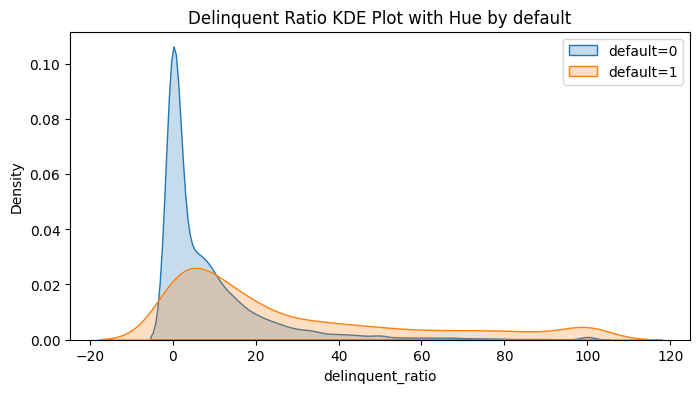

In [47]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['delinquent_ratio'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['delinquent_ratio'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Delinquent Ratio KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**
1. Blue graph has majority of its values on lower side of delinquent ratio
2. Orange graph has many values when delinquency ratio is higher indicating some correlation on default

In [48]:
# delinquent months can be 0 so we divide only when delinquent_month !=0 and if 0 will take ratio as 0
df_train_1["avg_dpd_per_delinquency"]=np.where(df_train_1["delinquent_months"]!=0,
    (df_train_1["total_dpd"]/df_train_1["delinquent_months"]).round(1),0)

df_test["avg_dpd_per_delinquency"]=np.where(df_test["delinquent_months"]!=0,
    (df_test["total_dpd"]/df_test["delinquent_months"]).round(1),0)


df_train_1["avg_dpd_per_delinquency"].describe()

count   37487.00
mean        3.29
std         2.90
min         0.00
25%         0.00
50%         4.30
75%         5.80
max        10.00
Name: avg_dpd_per_delinquency, dtype: float64

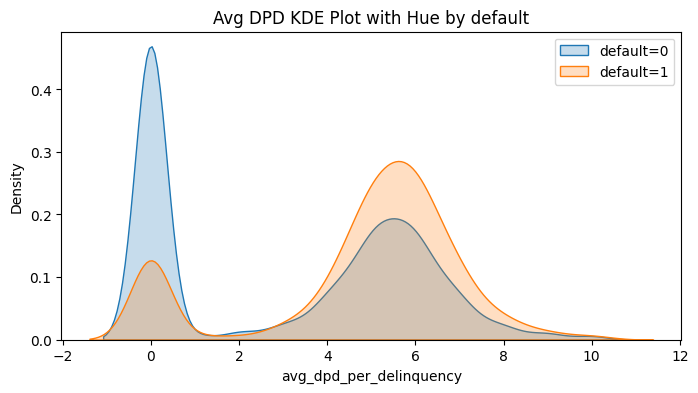

In [49]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1["avg_dpd_per_delinquency"][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1["avg_dpd_per_delinquency"][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Avg DPD KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**

1. Graph clearly shows more occurances of default cases when avg_dpd_per_delinquency is high. This means this column is a strong predictor

In [50]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'delinquent_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

### Feature Selection

In [51]:
# Remove columns that are just unique ids and don't have influence on target
df_train_2 = df_train_1.drop(["cust_id","loan_id"],axis='columns')
df_test = df_test.drop(["cust_id","loan_id"],axis='columns')

In [52]:
# Remove columns that business contact person asked us to remove
df_train_3 = df_train_2.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_test = df_test.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_train_3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquent_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [53]:
df_train_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37487 entries, 27434 to 15795
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37487 non-null  int64  
 1   gender                       37487 non-null  object 
 2   marital_status               37487 non-null  object 
 3   employment_status            37487 non-null  object 
 4   number_of_dependants         37487 non-null  int64  
 5   residence_type               37487 non-null  object 
 6   years_at_current_address     37487 non-null  int64  
 7   city                         37487 non-null  object 
 8   state                        37487 non-null  object 
 9   zipcode                      37487 non-null  int64  
 10  loan_purpose                 37487 non-null  object 
 11  loan_type                    37487 non-null  object 
 12  sanction_amount              37487 non-null  int64  
 13  processing_fee   

In [54]:
# converting default column to int32
df_train_3['default'] = df_train_3['default'].astype('int32')

#selection int64 and float64 columns 
df_train_3.select_dtypes(['int64', 'float64']).columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquent_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [55]:
# Scale features before VIF to ensure numerical stability and reliable multicollinearity estimates.
x_train = df_train_3.drop("default",axis=1)
y_train = df_train_3["default"]

cols_to_scale = df_train_3.select_dtypes(['int64', 'float64']).columns

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train[cols_to_scale]=scaler.fit_transform(x_train[cols_to_scale])
x_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquency
count,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00
mean,0.41,0.39,0.50,0.52,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.10,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.42,0.40,0.50,0.49,0.05,0.05,0.05,0.05,0.34,0.19,0.08,0.33,0.50,0.50,0.39,0.20,0.04,0.43
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.35,0.16,0.67,1.00,0.62,0.68,0.51,0.13,0.58
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [56]:
# same transformation on test data
x_test = df_test.drop("default",axis=1)
y_test = df_test["default"]


x_test[cols_to_scale]=scaler.transform(x_test[cols_to_scale])
x_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquency
count,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00
mean,0.41,0.39,0.50,0.52,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.10,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.42,0.40,0.50,0.49,0.05,0.05,0.05,0.05,0.34,0.19,0.08,0.33,0.50,0.50,0.39,0.20,0.04,0.43
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.35,0.16,0.67,1.00,0.62,0.68,0.51,0.13,0.58
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [58]:
calculate_vif(x_train[cols_to_scale])

C:\Users\Tanmay\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,5.72
1,number_of_dependants,2.73
2,years_at_current_address,3.42
3,zipcode,3.79
4,sanction_amount,102.15
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.14
9,principal_outstanding,16.28


In [59]:
# we will drop features having VIF more than 10
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement','principal_outstanding']


x_train_1 = x_train.drop(features_to_drop_vif, axis='columns')
numeric_columns = x_train_1.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquent_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [60]:
# checking vif again with our numeric columns
vif_df = calculate_vif(x_train_1[numeric_columns])
vif_df

,Column,VIF
0,age,5.45
1,number_of_dependants,2.73
2,years_at_current_address,3.41
3,zipcode,3.77
4,loan_tenure_months,5.98
5,bank_balance_at_application,1.80
6,number_of_open_accounts,4.32
7,number_of_closed_accounts,2.35
8,enquiry_count,6.37
9,credit_utilization_ratio,2.92


In [61]:
selected_numeric_features_vif = vif_df.Column.values
selected_numeric_features_vif

array(['age', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'enquiry_count', 'credit_utilization_ratio', 'loan_to_income',
       'delinquent_ratio', 'avg_dpd_per_delinquency'], dtype=object)

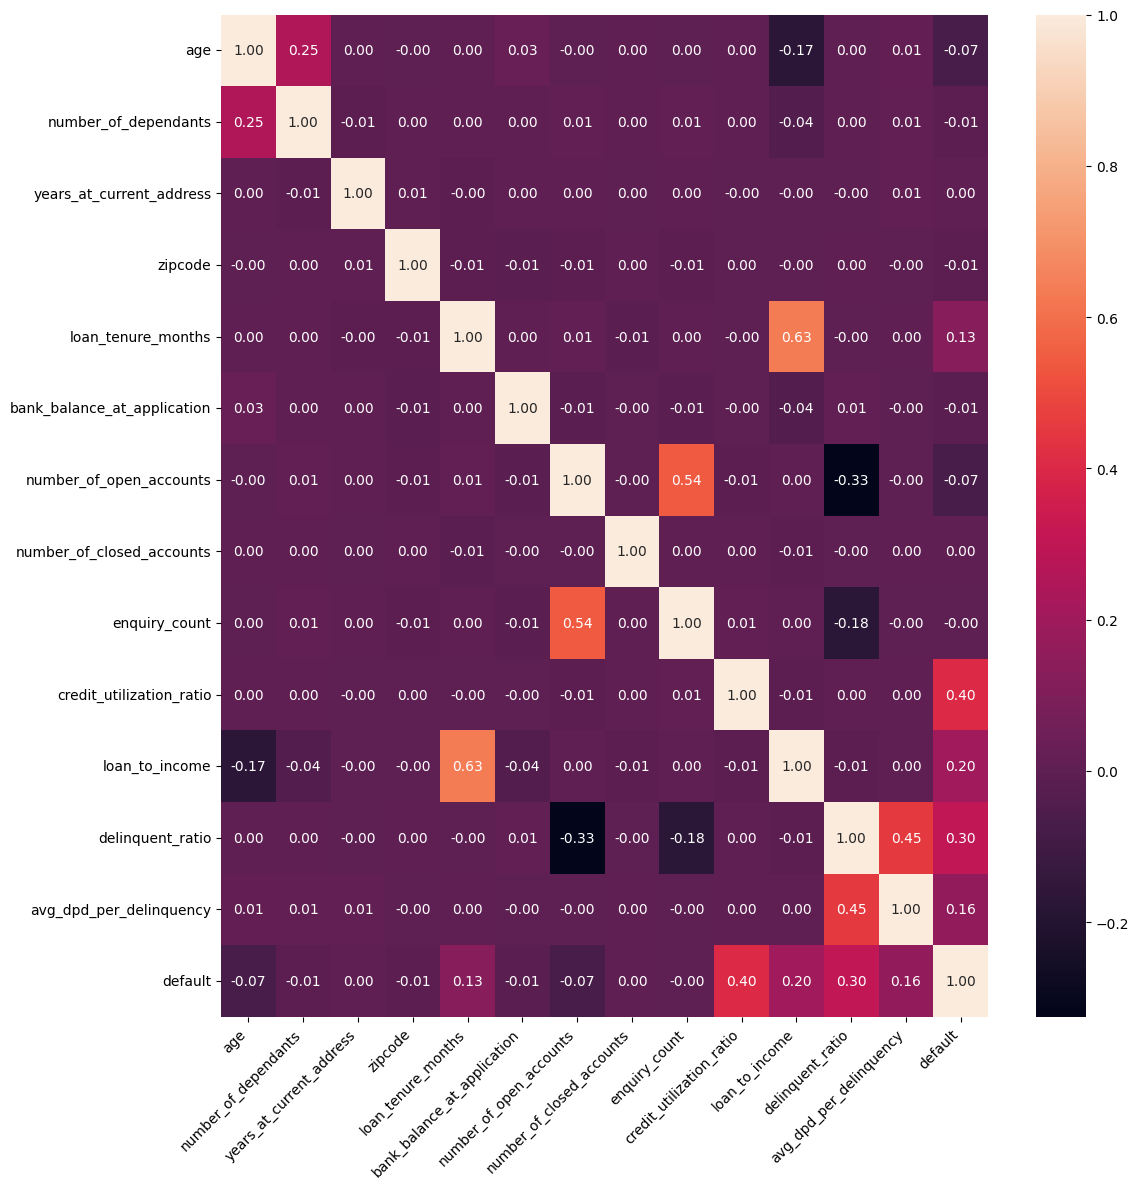

In [62]:
# correlation matrix
plt.figure(figsize=(12,12))
cm = df_train_3[numeric_columns.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot=True, fmt='0.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Categorical features selection

In [63]:
columns_categorical

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

### Weight of Evidence quantifies how well a feature separates good and bad outcomes, while Information Value measures the overall predictive strength of that feature. They are widely used in credit risk modeling for feature selection and encoding.

In [64]:
temp = pd.concat([x_train_1,y_train],axis=1)
temp.groupby('loan_purpose')['default'].agg(['count','sum'])

,count,sum
loan_purpose,,
Auto,7437,314
Education,5626,546
Home,11271,1744
Personal,13153,585


In [65]:
# Calculate WOE and IV
def calculate_woe_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad']=grouped['total']-grouped['good']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad
    grouped['woe'] = np.log(grouped['good_pct']/ grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct'] -grouped['bad_pct'])*grouped['woe']
    
    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv

grouped, total_iv = calculate_woe_iv(pd.concat([x_train_1, y_train],axis=1), 'loan_purpose', 'default')
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,7437,314,7123,0.10,0.21,-0.75,0.08
Education,5626,546,5080,0.17,0.15,0.14,0.00
Home,11271,1744,9527,0.55,0.28,0.68,0.18
Personal,13153,585,12568,0.18,0.37,-0.69,0.13


In [66]:
iv_values = {}

for feature in x_train_1.columns:
    if x_train_1[feature].dtype == 'object':
        _, iv = calculate_woe_iv(pd.concat([x_train_1, y_train],axis=1), feature, 'default' )
    else:
        x_binned = pd.cut(x_train_1[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([x_binned, y_train],axis=1), feature, 'default' )
    iv_values[feature] = iv
        
iv_values                               

{'age': np.float64(0.07592687127752061),
 'gender': np.float64(0.000482276463421216),
 'marital_status': np.float64(0.002196681370832318),
 'employment_status': np.float64(0.002447818101774487),
 'number_of_dependants': np.float64(0.00364589452118596),
 'residence_type': np.float64(0.2594019617563985),
 'years_at_current_address': np.float64(0.001042536380353028),
 'city': np.float64(0.000817870465334103),
 'state': np.float64(0.0007881984519711978),
 'zipcode': np.float64(0.0007436024782513755),
 'loan_purpose': np.float64(0.39377543144164784),
 'loan_type': np.float64(0.17304705897793143),
 'loan_tenure_months': np.float64(0.23450610202970526),
 'bank_balance_at_application': np.float64(0.004242001247914226),
 'number_of_open_accounts': np.float64(0.07324250836253295),
 'number_of_closed_accounts': np.float64(0.00026280824021760536),
 'enquiry_count': np.float64(0.005484982638303533),
 'credit_utilization_ratio': np.float64(2.4228228499400095),
 'loan_to_income': np.float64(0.4917403

In [67]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.423
19,delinquent_ratio,0.678
18,loan_to_income,0.492
20,avg_dpd_per_delinquency,0.421
10,loan_purpose,0.394
5,residence_type,0.259
12,loan_tenure_months,0.235
11,loan_type,0.173
0,age,0.076
14,number_of_open_accounts,0.073


In [68]:
# select features that has IV > 0.02
selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquent_ratio',
 'avg_dpd_per_delinquency']

### Feature Encoding

In [69]:
x_train_reduced = x_train_1[selected_features_iv]
x_test_reduced=x_test[selected_features_iv]

In [70]:
x_train_reduced.head()

,age,residence_type,loan_purpose,loan_type,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquency
27434,0.519,Owned,Home,Secured,0.340,1.000,0.596,0.609,0.067,0.550
13400,0.212,Owned,Auto,Secured,0.509,0.667,0.929,0.185,0.034,0.420
883,0.615,Mortgage,Personal,Unsecured,0.245,0.333,0.838,0.086,0.169,0.560
7303,0.481,Owned,Auto,Secured,0.283,0.000,0.343,0.187,0.000,0.000
45124,0.250,Owned,Education,Secured,0.736,0.333,0.192,0.363,0.097,0.470


In [71]:
x_train_encoded = pd.get_dummies(x_train_reduced,drop_first=True)
x_test_encoded = pd.get_dummies(x_test_reduced,drop_first=True)

x_train_encoded.head()

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
27434,0.519,0.340,1.000,0.596,0.609,0.067,0.550,True,False,False,True,False,False
13400,0.212,0.509,0.667,0.929,0.185,0.034,0.420,True,False,False,False,False,False
883,0.615,0.245,0.333,0.838,0.086,0.169,0.560,False,False,False,False,True,True
7303,0.481,0.283,0.000,0.343,0.187,0.000,0.000,True,False,False,False,False,False
45124,0.250,0.736,0.333,0.192,0.363,0.097,0.470,True,False,True,False,False,False


<h3 align="center" style="color:blue">Model Training</h3>

### Attempt 1

1. Logistic Regression, RandomForest & XGB
1. Without handling of class imbalance


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model=LogisticRegression()
model.fit(x_train_encoded,y_train)

y_pred = model.predict(x_test_encoded)
report= classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.84      0.69      0.76      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



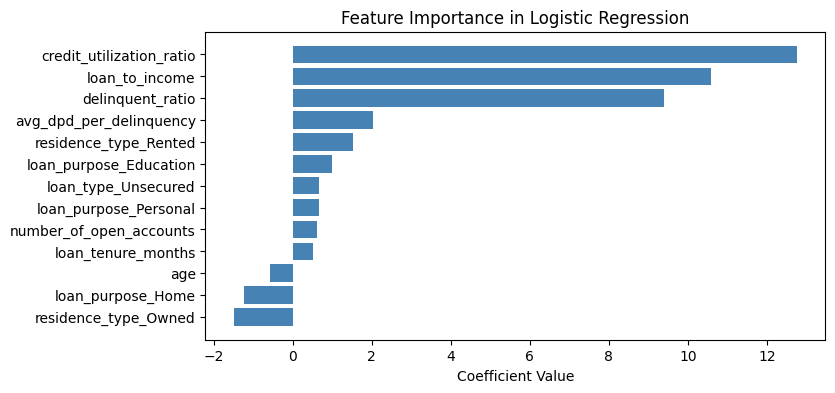

In [73]:
feature_importance = model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=x_train_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [74]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(x_train_encoded,y_train)

y_pred = model.predict(x_test_encoded)
report= classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.84      0.70      0.77      1108

    accuracy                           0.96     12498
   macro avg       0.91      0.85      0.87     12498
weighted avg       0.96      0.96      0.96     12498



In [75]:
from xgboost import XGBClassifier

model=RandomForestClassifier()
model.fit(x_train_encoded,y_train)

y_pred = model.predict(x_test_encoded)
report= classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.84      0.70      0.76      1108

    accuracy                           0.96     12498
   macro avg       0.91      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



Since there is not much difference between XGB and Logistic, we will choose LogisticRegression as a candidate for our RandomizedSearchCV candidate it has a better interpretation.

#### RandomizedSearch CV for Attempt 1: Logistic Regression

In [76]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': np.logspace(-4, 4, 20),  # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']   # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)  # Increased max_iter for convergence

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,  # 5-fold cross-validation
    verbose=2,
    random_state=42,  # Set a random state for reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(x_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(x_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'saga', 'C': np.float64(3792.690190732246)}
Best Score: 0.7633987551297344
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.83      0.71      0.77      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.85      0.87     12498
weighted avg       0.96      0.96      0.96     12498



#### RandomizedSearch CV for Attempt 1: XGBoost

In [77]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # L1 regularization term
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]  # L2 regularization term
}

xgb = XGBClassifier()

random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100,
                                   scoring='f1', cv=3, verbose=1, n_jobs=-1, random_state=42)

random_search.fit(x_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(x_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'subsample': 0.7, 'scale_pos_weight': 2, 'reg_lambda': 10.0, 'reg_alpha': 0.01, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best Score: 0.7940934373265193
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11390
           1       0.77      0.82      0.79      1108

    accuracy                           0.96     12498
   macro avg       0.88      0.90      0.89     12498
weighted avg       0.96      0.96      0.96     12498



### Attempt 2

1. Logistic Regression & XGB
1. Handle Class Imbalance Using Under Sampling

In [78]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
x_train_res, y_train_res = rus.fit_resample(x_train_encoded, y_train)
y_train_res.value_counts()

default
0    3189
1    3189
Name: count, dtype: int64

In [79]:
model = LogisticRegression()
model.fit(x_train_res, y_train_res)

y_pred = model.predict(x_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.92      0.96     11390
           1       0.53      0.95      0.68      1108

    accuracy                           0.92     12498
   macro avg       0.76      0.93      0.82     12498
weighted avg       0.95      0.92      0.93     12498



In [80]:
model = XGBClassifier(**random_search.best_params_)
model.fit(x_train_res, y_train_res)

y_pred = model.predict(x_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11390
           1       0.53      0.98      0.69      1108

    accuracy                           0.92     12498
   macro avg       0.77      0.95      0.82     12498
weighted avg       0.96      0.92      0.93     12498



### Note:
In credit risk modeling, the main goal is to avoid giving loans to people who will default.

Recall (for defaulters) = how many actual defaulters we correctly identify

Precision = how many predicted defaulters are actually defaulters

If recall is low → you miss defaulters → bad customers get loans → financial loss
If precision is low → you wrongly reject some good customers → lost business, but no direct loss

So the trade-off is:
High recall → safer (catch most risky customers)
Lower precision → acceptable (rejecting some good customers is less harmful)

That’s why in credit risk, missing a defaulter is far worse than rejecting a good customer, so we prioritize recall over precision.

### Attempt 3

1. Logistic Regression
1. Handle Class Imbalance Using SMOTE Tomek
1. Parameter tunning using optuna

In [81]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
x_train_smt, y_train_smt = smt.fit_resample(x_train_encoded, y_train)
y_train_smt.value_counts()

default
0    34224
1    34224
Name: count, dtype: int64

In [82]:
model = LogisticRegression()
model.fit(x_train_smt, y_train_smt)

y_pred = model.predict(x_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.83     12498
weighted avg       0.96      0.93      0.94     12498



In [83]:
import optuna
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

In [84]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weights
    }

    model = LogisticRegression(**param, max_iter=10000)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, x_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)

[I 2026-03-25 09:41:52,843] A new study created in memory with name: no-name-7c1908ae-bd8a-459b-8701-c3238debde7d
[I 2026-03-25 09:41:53,096] Trial 0 finished with value: 0.9415753138126539 and parameters: {'C': 0.15036827564937988, 'solver': 'newton-cg', 'tol': 0.00011831430785939228, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9415753138126539.
[I 2026-03-25 09:41:53,212] Trial 1 finished with value: 0.9043313035506698 and parameters: {'C': 80.08450913075485, 'solver': 'lbfgs', 'tol': 0.01905771259901482, 'class_weight': None}. Best is trial 0 with value: 0.9415753138126539.
[I 2026-03-25 09:41:53,358] Trial 2 finished with value: 0.8990601794324959 and parameters: {'C': 0.002711148254760685, 'solver': 'liblinear', 'tol': 0.038857758677151334, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9415753138126539.
[I 2026-03-25 09:41:53,489] Trial 3 finished with value: 0.8466447029243951 and parameters: {'C': 0.00020824857985380523, 'solver': 'lbfgs', 'tol': 0.00

In [85]:
print('Best trial:')
trial = study_logistic.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(x_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_logistic.predict(x_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.945141295403661
  Params: 
    C: 11.225189983646727
    solver: lbfgs
    tol: 0.00012384135559856654
    class_weight: None
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.93      0.83     12498
weighted avg       0.96      0.93      0.94     12498



### Attempt 4

1. XGBoost
1. Handle Class Imbalance Using SMOTE Tomek
1. Parameter tunning using optuna

In [86]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity': 0,
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model = XGBClassifier(**param)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, x_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

[I 2026-03-25 09:42:04,575] A new study created in memory with name: no-name-15b636c8-6017-4f38-9519-6d872d91d2b5
[I 2026-03-25 09:42:05,261] Trial 0 finished with value: 0.9148157773185716 and parameters: {'lambda': 0.04886976776702048, 'alpha': 0.043073967140745184, 'subsample': 0.5961124717341465, 'colsample_bytree': 0.8275057253723614, 'max_depth': 3, 'eta': 0.016495347466228383, 'gamma': 3.503764405992933, 'scale_pos_weight': 1.5132550342269904, 'min_child_weight': 10, 'max_delta_step': 7}. Best is trial 0 with value: 0.9148157773185716.
[I 2026-03-25 09:42:05,992] Trial 1 finished with value: 0.9603403119132229 and parameters: {'lambda': 0.05124305053610886, 'alpha': 0.33038683898642107, 'subsample': 0.5381259328073346, 'colsample_bytree': 0.6383479530539968, 'max_depth': 6, 'eta': 0.17007612788622664, 'gamma': 9.48889556563806, 'scale_pos_weight': 4.659613933805739, 'min_child_weight': 6, 'max_delta_step': 7}. Best is trial 1 with value: 0.9603403119132229.
[I 2026-03-25 09:42:0

In [87]:
print('Best trial:')
trial = study_xgb.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_params = study_xgb.best_params
best_model_xgb = XGBClassifier(**best_params)
best_model_xgb.fit(x_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_xgb.predict(x_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.9774674211735116
  Params: 
    lambda: 0.013541213952655345
    alpha: 0.012738987493079638
    subsample: 0.8523047052588639
    colsample_bytree: 0.7788108423789375
    max_depth: 10
    eta: 0.22011871478056844
    gamma: 0.04645440351480412
    scale_pos_weight: 1.5861007029353993
    min_child_weight: 3
    max_delta_step: 1
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11390
           1       0.74      0.83      0.78      1108

    accuracy                           0.96     12498
   macro avg       0.86      0.90      0.88     12498
weighted avg       0.96      0.96      0.96     12498



<h3 align="center" style="color:blue">Model Evaluation</h3>

## Model Evaluation : ROC/AUC

In [88]:
# we comapred recall of each model we are getting good result in best_model_logistic so we will choose that.
y_pred = best_model_logistic.predict(x_test_encoded)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.93      0.83     12498
weighted avg       0.96      0.93      0.94     12498



In [89]:
from sklearn.metrics import roc_curve

probabilities=best_model_logistic.predict_proba(x_test_encoded)[:,1]
probabilities

fpr,tpr,thresholds=roc_curve(y_test,probabilities)
fpr[:10],tpr[:10],thresholds[:10]

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.77963126e-05,
        8.77963126e-05, 1.75592625e-04, 1.75592625e-04, 2.63388938e-04,
        2.63388938e-04, 3.51185250e-04]),
 array([0.        , 0.00090253, 0.20577617, 0.20577617, 0.22111913,
        0.22111913, 0.26444043, 0.26444043, 0.30685921, 0.30685921]),
 array([       inf, 0.99999995, 0.99892576, 0.99889703, 0.99869916,
        0.9986969 , 0.99773775, 0.99770845, 0.9967403 , 0.99671365]))

In [90]:
from sklearn.metrics import auc

area = auc(fpr, tpr)
area

0.9829614139960635

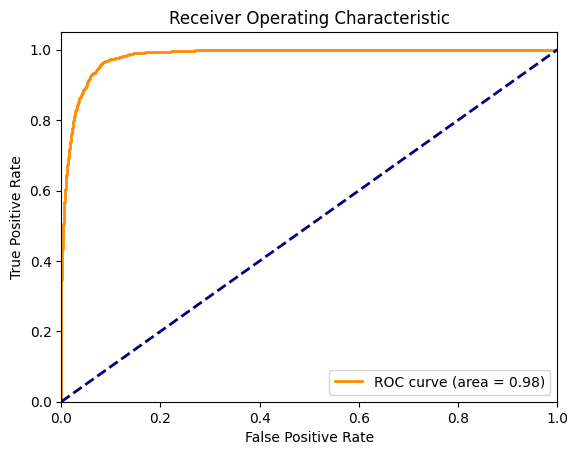

In [91]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Model Evaluation : Rankordering, KS statistic, Gini coeff

In [92]:
probabilities = best_model_logistic.predict_proba(x_test_encoded)[:,1]

df_eval = pd.DataFrame({
    'Default Truth': y_test,
    'Default Probability': probabilities
})
df_eval.head(3)

,Default Truth,Default Probability
33553,0,0.000
9427,0,0.772
199,0,0.137


In [93]:
df_eval['Decile'] = pd.qcut(df_eval['Default Probability'], 10, labels=False, duplicates='drop')
df_eval.head(3)

,Default Truth,Default Probability,Decile
33553,0,0.000,1
9427,0,0.772,8
199,0,0.137,7


In [94]:
df_eval[df_eval.Decile==8]['Default Probability'].describe()

count   1250.000
mean       0.491
std        0.188
min        0.205
25%        0.324
50%        0.475
75%        0.660
max        0.822
Name: Default Probability, dtype: float64

In [95]:
df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({
    'Minimum Probability': x['Default Probability'].min(),
    'Maximum Probability': x['Default Probability'].max(),
    'Events': x['Default Truth'].sum(),
    'Non-events': x['Default Truth'].count() - x['Default Truth'].sum(),    
}))
df_decile.reset_index(inplace=True)
df_decile

C:\Users\Tanmay\AppData\Local\Temp\ipykernel_17796\4037021561.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({


,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,0.000,0.000,0.000,1250.000
1,1,0.000,0.000,0.000,1250.000
2,2,0.000,0.000,0.000,1250.000
3,3,0.000,0.000,0.000,1249.000
4,4,0.000,0.001,0.000,1250.000
5,5,0.001,0.005,1.000,1249.000
6,6,0.005,0.031,2.000,1247.000
7,7,0.031,0.204,17.000,1233.000
8,8,0.205,0.822,170.000,1080.000
9,9,0.823,1.000,918.000,332.000


In [96]:
df_decile['Event Rate'] = df_decile['Events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile['Non-event Rate'] = df_decile['Non-events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,0,0.000,0.000,0.000,1250.000,0.000,100.000
1,1,0.000,0.000,0.000,1250.000,0.000,100.000
2,2,0.000,0.000,0.000,1250.000,0.000,100.000
3,3,0.000,0.000,0.000,1249.000,0.000,100.000
4,4,0.000,0.001,0.000,1250.000,0.000,100.000
5,5,0.001,0.005,1.000,1249.000,0.080,99.920
6,6,0.005,0.031,2.000,1247.000,0.160,99.840
7,7,0.031,0.204,17.000,1233.000,1.360,98.640
8,8,0.205,0.822,170.000,1080.000,13.600,86.400
9,9,0.823,1.000,918.000,332.000,73.440,26.560


In [97]:
df_decile = df_decile.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,9,0.823,1.000,918.000,332.000,73.440,26.560
1,8,0.205,0.822,170.000,1080.000,13.600,86.400
2,7,0.031,0.204,17.000,1233.000,1.360,98.640
3,6,0.005,0.031,2.000,1247.000,0.160,99.840
4,5,0.001,0.005,1.000,1249.000,0.080,99.920
5,4,0.000,0.001,0.000,1250.000,0.000,100.000
6,3,0.000,0.000,0.000,1249.000,0.000,100.000
7,2,0.000,0.000,0.000,1250.000,0.000,100.000
8,1,0.000,0.000,0.000,1250.000,0.000,100.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000


In [98]:
df_decile['Cum Events'] =  df_decile['Events'].cumsum()
df_decile['Cum Non-events'] =  df_decile['Non-events'].cumsum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events
0,9,0.823,1.000,918.000,332.000,73.440,26.560,918.000,332.000
1,8,0.205,0.822,170.000,1080.000,13.600,86.400,1088.000,1412.000
2,7,0.031,0.204,17.000,1233.000,1.360,98.640,1105.000,2645.000
3,6,0.005,0.031,2.000,1247.000,0.160,99.840,1107.000,3892.000
4,5,0.001,0.005,1.000,1249.000,0.080,99.920,1108.000,5141.000
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1108.000,6391.000
6,3,0.000,0.000,0.000,1249.000,0.000,100.000,1108.000,7640.000
7,2,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,8890.000
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,10140.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,11390.000


In [99]:
df_decile['Cum Event Rate'] = df_decile['Cum Events'] * 100 / df_decile['Events'].sum()
df_decile['Cum Non-event Rate'] = df_decile['Cum Non-events']*100 / df_decile['Non-events'].sum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
0,9,0.823,1.000,918.000,332.000,73.440,26.560,918.000,332.000,82.852,2.915
1,8,0.205,0.822,170.000,1080.000,13.600,86.400,1088.000,1412.000,98.195,12.397
2,7,0.031,0.204,17.000,1233.000,1.360,98.640,1105.000,2645.000,99.729,23.222
3,6,0.005,0.031,2.000,1247.000,0.160,99.840,1107.000,3892.000,99.910,34.170
4,5,0.001,0.005,1.000,1249.000,0.080,99.920,1108.000,5141.000,100.000,45.136
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1108.000,6391.000,100.000,56.111
6,3,0.000,0.000,0.000,1249.000,0.000,100.000,1108.000,7640.000,100.000,67.076
7,2,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,8890.000,100.000,78.051
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,10140.000,100.000,89.025
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,11390.000,100.000,100.000


In [100]:
df_decile['KS'] = abs(df_decile['Cum Event Rate'] - df_decile['Cum Non-event Rate'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
0,9,0.823,1.000,918.000,332.000,73.440,26.560,918.000,332.000,82.852,2.915,79.937
1,8,0.205,0.822,170.000,1080.000,13.600,86.400,1088.000,1412.000,98.195,12.397,85.798
2,7,0.031,0.204,17.000,1233.000,1.360,98.640,1105.000,2645.000,99.729,23.222,76.507
3,6,0.005,0.031,2.000,1247.000,0.160,99.840,1107.000,3892.000,99.910,34.170,65.739
4,5,0.001,0.005,1.000,1249.000,0.080,99.920,1108.000,5141.000,100.000,45.136,54.864
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1108.000,6391.000,100.000,56.111,43.889
6,3,0.000,0.000,0.000,1249.000,0.000,100.000,1108.000,7640.000,100.000,67.076,32.924
7,2,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,8890.000,100.000,78.051,21.949
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,10140.000,100.000,89.025,10.975
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,11390.000,100.000,100.000,0.000


To assess whether rank ordering is followed, we should look at whether higher deciles (those with higher predicted probabilities) have higher event rates compared to lower deciles. Rank ordering means that as you move from the top decile to the bottom decile, the event rate should generally decrease.

Non-Events - termed as good (customers) who do not default. Events - termed as bad (customers) who default.

Events and Non-Events terms are interchanged based on usecase to usecase.

eg: for marketing usecase, which customer to reach out (who will take loan based on offers) will be events - here it will termed as good, and the customers who will not take loans will be non-events (bad).

**Insights from the Decile Table**

1. Top Deciles

* The first decile (Decile 9) has a high event rate of 72.00% and a non-event rate of 28.00%. This indicates that the model is highly confident in predicting events in this decile.
* The second decile (Decile 8) also shows a significant event rate of 12.72%, with a cumulative event rate reaching 98.6%.

2. Middle Deciles:

* Deciles 7 and 6 show a significant drop in event rates

3. Lower Deciles:

* Deciles 5 to 0 show zero events, with all predictions being non-events. These deciles collectively have a non-event rate of 100%.

4. KS Statistic:

* The KS statistic, which is the maximum difference between cumulative event rates and cumulative non-event rates, is highest at Decile 8 with a value of 85.98%. This suggests that the model performs best at distinguishing between events and non-events up to this decile.

* The KS value gradually decreases in the following deciles, indicating a decrease in model performance for distinguishing between events and non-events.

**KS Value**

The highest KS value is 85.98%, found at Decile 8. This indicates that the model's performance in distinguishing between events and non-events is most significant at this decile. (If KS is in top 3 decile and score above 40, it is considered a good predictive model.)

In [101]:
gini_coefficient = 2 * area - 1

print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.9829614139960635
Gini Coefficient: 0.965922827992127


AUC of 0.98: The model is very good at distinguishing between events and non-events.

Gini coefficient of 0.96: This further confirms that the model is highly effective in its predictions, with almost perfect rank ordering capability.

The Gini coefficient ranges from -1 to 1, where a value closer to 1 signifies a perfect model, 0 indicates a model with no discriminative power, and -1 signifies a perfectly incorrect model.

#### Finalize The Model and Visualize Feature Importance

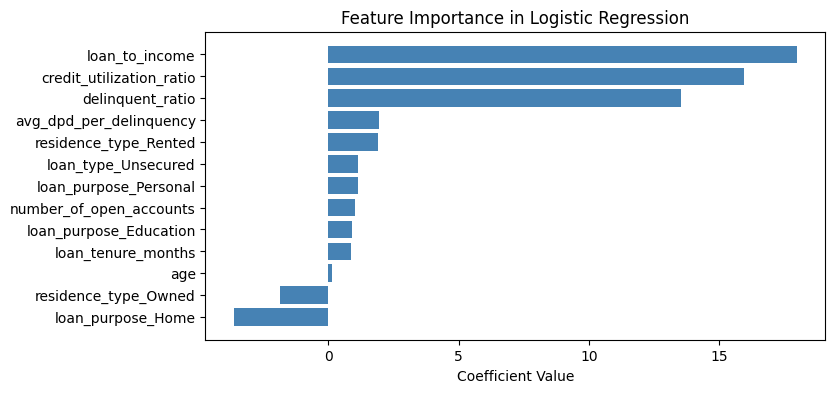

In [102]:
final_model = best_model_logistic

feature_importance = final_model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=x_train_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

### Saving the Model

In [103]:
x_test_encoded.head(2)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
33553,0.346,0.528,0.333,0.121,0.258,0.043,0.900,True,False,True,False,False,False
9427,0.288,0.623,1.000,0.859,0.690,0.000,0.000,True,False,False,True,False,False


In [104]:
x_test_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquent_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')

In [105]:
cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquent_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [106]:
x_train_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquent_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')

In [107]:
from joblib import dump

model_data = {
    'model': final_model,
    'features': x_train_encoded.columns,
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(model_data, 'artifacts/model_data.joblib')

FileNotFoundError: [Errno 2] No such file or directory: 'artifacts/model_data.joblib'

In [ ]:
final_model.coef_, final_model.intercept_

In [ ]:
!pip list